In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

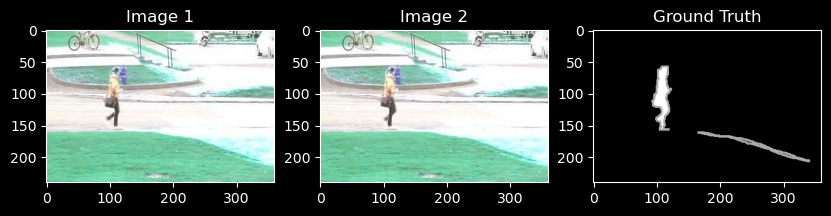

In [20]:
pedestrain_dir = "data/pedestrian"
pedestrinan_input_dir = pedestrain_dir + "/input"
pedestrian_ground_truth_dir = pedestrain_dir + "/groundtruth"

idx = 350

def load_2_images(path, from_idx=1, skip=1):
    idx_6_digits = str(from_idx).zfill(6)
    idx_6_digits_skip = str(from_idx + skip).zfill(6)
    img1 = cv2.imread(f"{path}/in{idx_6_digits}.jpg")
    img2 = cv2.imread(f"{path}/in{idx_6_digits_skip}.jpg")
    ground_truth = cv2.imread(f"{pedestrian_ground_truth_dir}/gt{idx_6_digits_skip}.png")
    return img1, img2, ground_truth

img1, img2, ground_truth = load_2_images(pedestrinan_input_dir, from_idx=idx, skip=1)

f, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img1)
ax[0].set_title("Image 1")
ax[1].imshow(img2)
ax[1].set_title("Image 2")
ax[2].imshow(ground_truth)
ax[2].set_title("Ground Truth")
plt.show()



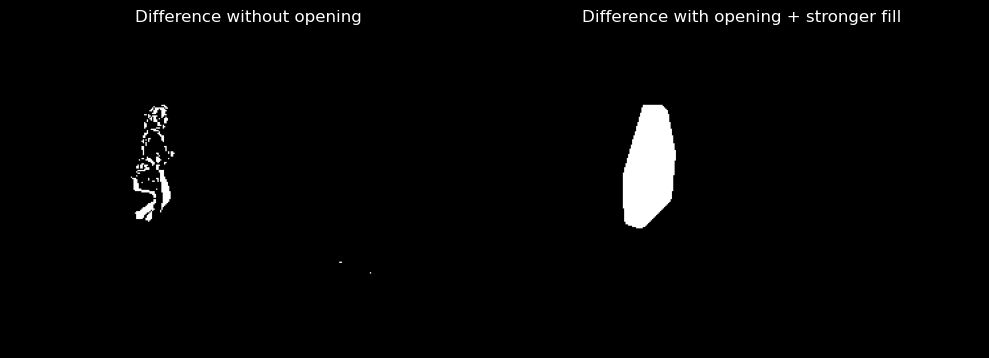

In [21]:
def show_diff(
    img1,
    img2,
    ax=None,
    with_opening=False,
    fill_regions=False,
    min_area=80,
    dilate_ksize=10,
    close_ksize=12,
    dilate_iter=1,
    close_iter=2,
    use_convex_hull=True,
    ):
    diff = cv2.absdiff(img1, img2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    (T, thresh) = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if with_opening:
        open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, open_kernel)

    if fill_regions:
        dilate_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (dilate_ksize, dilate_ksize)
        )
        close_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (close_ksize, close_ksize)
        )
        grown = cv2.dilate(thresh, dilate_kernel, iterations=dilate_iter)
        closed = cv2.morphologyEx(grown, cv2.MORPH_CLOSE, close_kernel, iterations=close_iter)

        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        filled = np.zeros_like(closed)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            if use_convex_hull:
                cnt = cv2.convexHull(cnt)
            cv2.drawContours(filled, [cnt], -1, 255, thickness=cv2.FILLED)

        thresh = filled

    if ax is not None:
        ax.imshow(thresh, cmap="gray")
        ax.axis("off")

    return T, thresh

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Difference without opening")
T_no_open, _ = show_diff(img1, img2, ax[0], with_opening=False, fill_regions=False)

ax[1].set_title("Difference with opening + stronger fill")
T_open, _ = show_diff(img1, img2, ax[1], with_opening=True, fill_regions=True)

plt.tight_layout()
plt.show()

array([[    0,     0,   360,   240, 83598],
       [   91,    57,    40,    93,  2802]], dtype=int32)

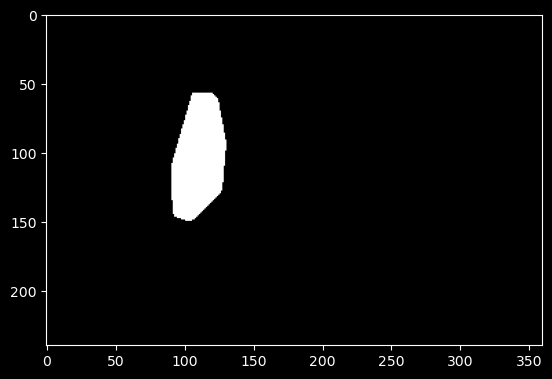

In [22]:

_, thresh = show_diff(img1, img2, with_opening=True, fill_regions=True)

retval, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

plt.imshow((labels / retval) * 255, cmap="gray")

stats

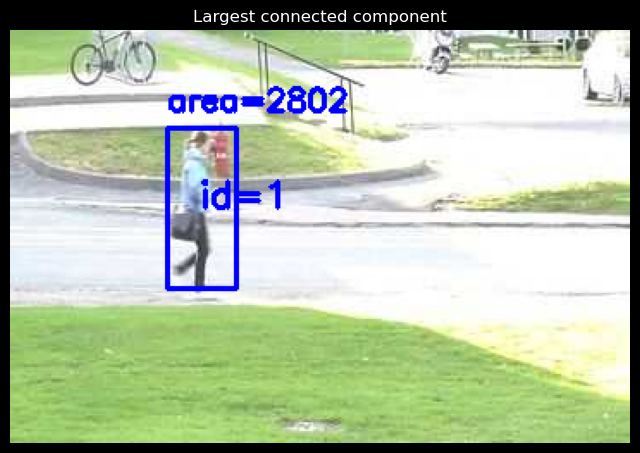

In [23]:
I_VIS = img1.copy()

if stats.shape[0] > 1:
    pi = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    x = stats[pi, cv2.CC_STAT_LEFT]
    y = stats[pi, cv2.CC_STAT_TOP]
    w = stats[pi, cv2.CC_STAT_WIDTH]
    h = stats[pi, cv2.CC_STAT_HEIGHT]
    area = stats[pi, cv2.CC_STAT_AREA]

    cv2.rectangle(I_VIS, (x, y), (x + w, y + h), (255, 0, 0), 2)

    cv2.putText(
        I_VIS, f"area={area}", (x, max(0, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
    )

    cx, cy = centroids[pi].astype(int)
    cv2.putText(
        I_VIS, f"id={pi}", (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2
    )
else:
    print("No foreground objects detected.")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(I_VIS, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Largest connected component")
plt.show()

In [24]:
def evaluate_binary_mask(pred_mask, gt_mask, ignore_gt_values=(50, 85, 170)):
    if pred_mask.ndim == 3:
        pred_mask = cv2.cvtColor(pred_mask, cv2.COLOR_BGR2GRAY)
    if gt_mask.ndim == 3:
        gt_mask = cv2.cvtColor(gt_mask, cv2.COLOR_BGR2GRAY)

    valid = np.ones_like(gt_mask, dtype=bool)
    for v in ignore_gt_values:
        valid &= (gt_mask != v)

    # binarization
    pred_fg = (pred_mask == 255)
    gt_fg = (gt_mask == 255)

    pred_fg = pred_fg[valid]
    gt_fg = gt_fg[valid]

    tp = int(np.sum(pred_fg & gt_fg))
    fp = int(np.sum(pred_fg & (~gt_fg)))
    tn = int(np.sum((~pred_fg) & (~gt_fg)))
    fn = int(np.sum((~pred_fg) & gt_fg))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

_, pred_mask = show_diff(img1, img2, with_opening=True)
metrics = evaluate_binary_mask(pred_mask, ground_truth)
metrics

{'TN': 83345,
 'FP': 37,
 'FN': 903,
 'TP': 157,
 'precision': 0.8092783505154639,
 'recall': 0.1481132075471698,
 'f1': 0.25039872408293457}

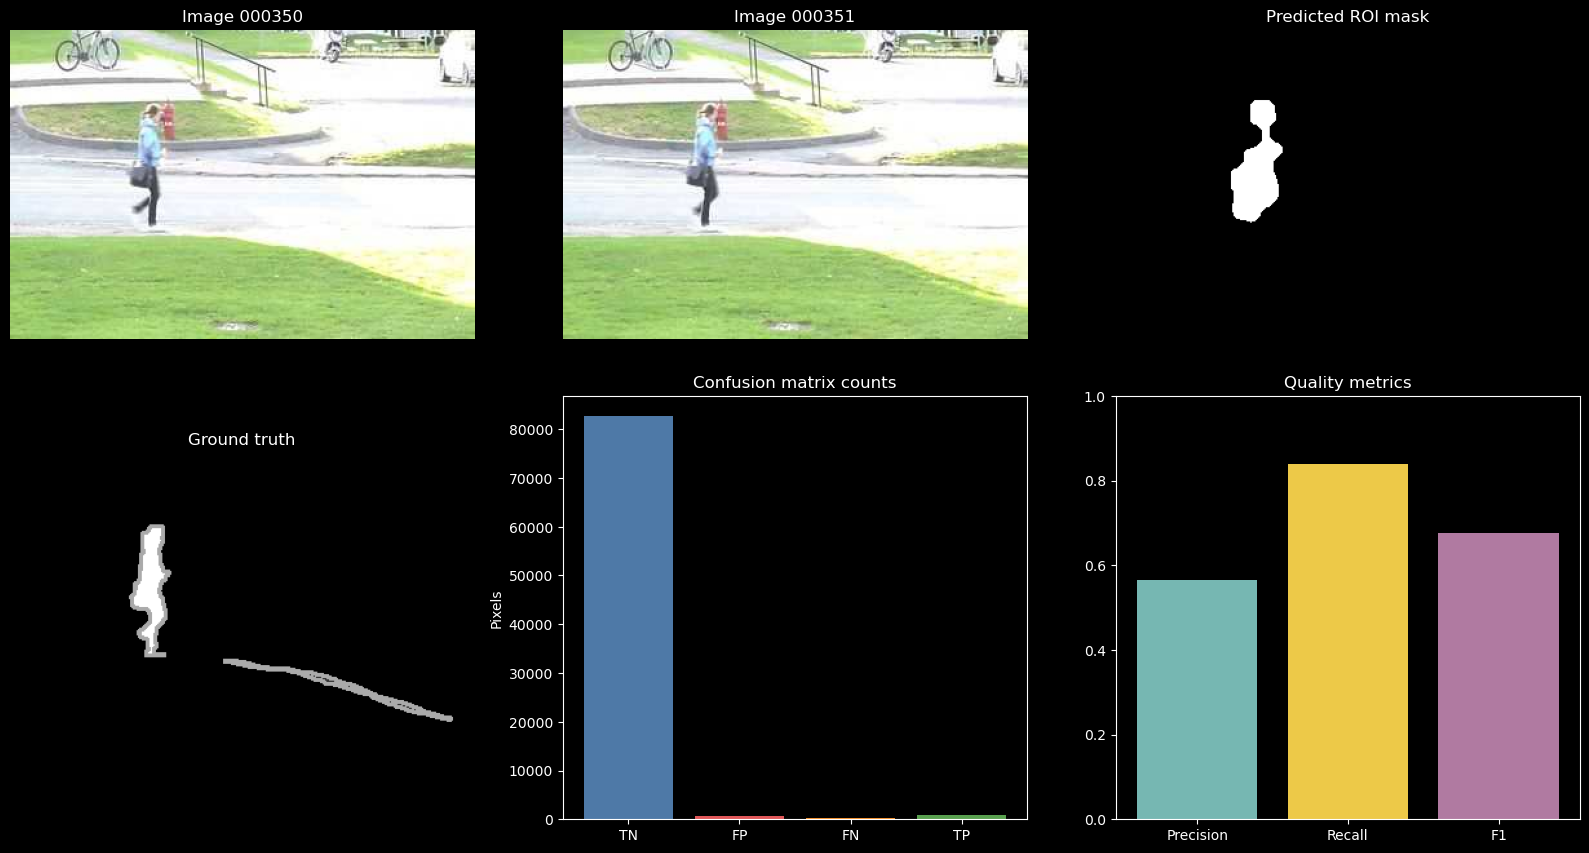

Frame pair: 000350 -> 000351
TN=82696, FP=686, FN=170, TP=890 | P=0.5647, R=0.8396, F1=0.6753


{'TN': 82696,
 'FP': 686,
 'FN': 170,
 'TP': 890,
 'precision': 0.5647208121827412,
 'recall': 0.839622641509434,
 'f1': 0.6752655538694993}

In [25]:
def evaluate_frame(
    index,
    input_dir=pedestrinan_input_dir,
    step=1,
    with_opening=True,
    fill_regions=True,
    **diff_kwargs,
    ):
    img1, img2, gt = load_2_images(input_dir, from_idx=index, skip=step)
    _, pred_mask = show_diff(
        img1,
        img2,
        with_opening=with_opening,
        fill_regions=fill_regions,
        **diff_kwargs,
    )
    m = evaluate_binary_mask(pred_mask, gt)

    fig, ax = plt.subplots(2, 3, figsize=(16, 9))

    ax[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    ax[0, 0].set_title(f"Image {index:06d}")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    ax[0, 1].set_title(f"Image {index + step:06d}")
    ax[0, 1].axis("off")

    ax[0, 2].imshow(pred_mask, cmap="gray")
    ax[0, 2].set_title("Predicted ROI mask")
    ax[0, 2].axis("off")

    gt_gray = cv2.cvtColor(gt, cv2.COLOR_BGR2GRAY) if gt.ndim == 3 else gt
    ax[1, 0].imshow(gt_gray, cmap="gray")
    ax[1, 0].set_title("Ground truth")
    ax[1, 0].axis("off")

    labels = ["TN", "FP", "FN", "TP"]
    values = [m["TN"], m["FP"], m["FN"], m["TP"]]
    ax[1, 1].bar(labels, values, color=["#4E79A7", "#E15759", "#F28E2B", "#59A14F"] )
    ax[1, 1].set_title("Confusion matrix counts")
    ax[1, 1].set_ylabel("Pixels")

    prf_labels = ["Precision", "Recall", "F1"]
    prf_values = [m["precision"], m["recall"], m["f1"]]
    ax[1, 2].bar(prf_labels, prf_values, color=["#76B7B2", "#EDC948", "#B07AA1"] )
    ax[1, 2].set_ylim(0, 1)
    ax[1, 2].set_title("Quality metrics")

    plt.tight_layout()
    plt.show()

    print(f"Frame pair: {index:06d} -> {index + step:06d}")
    print(
        f"TN={m['TN']}, FP={m['FP']}, FN={m['FN']}, TP={m['TP']} | "
        f"P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}"
    )

    return m


# Example call (less aggressive fill than defaults in show_diff)
frame_metrics = evaluate_frame(
    index=idx,
    step=1,
    with_opening=True,
    fill_regions=True,
    use_convex_hull=False,
    dilate_ksize=10,
    close_ksize=11,
    min_area=50,
    )
frame_metrics

In [ ]:
# Build an annotated MP4 for a frame range using the same settings as your evaluate_frame example.
out_video = "data/pedestrian/metrics_350_450.mp4"
start_idx, end_idx = 350, 450

def render_metrics_video(
    out_path,
    start_idx=350,
    end_idx=450,
    step=1,
    fps=12,
    with_opening=True,
    fill_regions=True,
    **diff_kwargs,
    ):
    first_img, _, _ = load_2_images(pedestrinan_input_dir, from_idx=start_idx, skip=step)
    if first_img is None:
        raise ValueError(f"Could not read start frame {start_idx:06d}")

    h, w = first_img.shape[:2]
    writer = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h),
    )

    if not writer.isOpened():
        raise RuntimeError(f"Failed to open video writer for: {out_path}")

    # Scale text and box size for small frames (e.g., ~300x200).
    scale_factor = min(w / 1280.0, h / 720.0)
    font_scale_main = max(0.30, min(0.55, 0.65 * scale_factor + 0.22))
    font_scale_small = max(0.25, min(0.45, 0.55 * scale_factor + 0.18))
    thick_main = 1 if font_scale_main < 0.5 else 2
    thick_small = 1
    pad = 6
    line_gap = max(10, int(16 * (font_scale_main / 0.55)))

    for i in range(start_idx, end_idx + 1):
        img1, img2, gt = load_2_images(pedestrinan_input_dir, from_idx=i, skip=step)
        if img1 is None or img2 is None or gt is None:
            print(f"Stopping early at frame {i:06d} due to missing input/GT file.")
            break

        _, pred_mask = show_diff(
            img1,
            img2,
            with_opening=with_opening,
            fill_regions=fill_regions,
            **diff_kwargs,
        )
        m = evaluate_binary_mask(pred_mask, gt)

        # Draw predicted foreground mask in red on top of current frame.
        vis = img2.copy()
        fg = pred_mask == 255
        vis[fg] = (0, 0, 255)

        # Compact annotation block sized to frame resolution.
        line1 = f"Frame: {i:06d}"
        line2 = f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}"
        line3 = f"TP={m['TP']} FP={m['FP']} FN={m['FN']}"

        (w1, h1), _ = cv2.getTextSize(line1, cv2.FONT_HERSHEY_SIMPLEX, font_scale_main, thick_main)
        (w2, h2), _ = cv2.getTextSize(line2, cv2.FONT_HERSHEY_SIMPLEX, font_scale_small, thick_small)
        (w3, h3), _ = cv2.getTextSize(line3, cv2.FONT_HERSHEY_SIMPLEX, font_scale_small, thick_small)

        box_w = min(max(w1, w2, w3) + 2 * pad, w - 2 * pad)
        box_h = h1 + h2 + h3 + 3 * line_gap
        x0, y0 = pad, pad
        x1, y1 = x0 + box_w, min(y0 + box_h, h - pad)

        overlay = vis.copy()
        cv2.rectangle(overlay, (x0, y0), (x1, y1), (0, 0, 0), thickness=-1)
        cv2.addWeighted(overlay, 0.45, vis, 0.55, 0, vis)

        y_text = y0 + line_gap
        cv2.putText(vis, line1, (x0 + pad, y_text), cv2.FONT_HERSHEY_SIMPLEX, font_scale_main, (255, 255, 255), thick_main)
        y_text += line_gap
        cv2.putText(vis, line2, (x0 + pad, y_text), cv2.FONT_HERSHEY_SIMPLEX, font_scale_small, (255, 255, 255), thick_small)
        y_text += line_gap
        cv2.putText(vis, line3, (x0 + pad, y_text), cv2.FONT_HERSHEY_SIMPLEX, font_scale_small, (210, 210, 255), thick_small)

        writer.write(vis)

    writer.release()
    print(f"Saved: {out_path}")

render_metrics_video(
    out_path=out_video,
    start_idx=start_idx,
    end_idx=end_idx,
    step=1,
    fps=12,
    with_opening=True,
    fill_regions=True,
    use_convex_hull=False,
    dilate_ksize=10,
    close_ksize=11,
    min_area=50,
    )

Saved: data/pedestrian/metrics_350_400.mp4
